In [6]:
import dipy
import os
import subprocess
import nibabel as nib
import numpy as np
from dipy.core.gradients import gradient_table
from dipy.io.image import load_nifti, save_nifti
from dipy.reconst.dti import TensorModel
from dipy.align.imaffine import AffineMap, MutualInformationMetric, AffineRegistration
from dipy.align.transforms import TranslationTransform3D, RigidTransform3D
import os
import sys
sys.path.append('../../')
from cardpy.Sample_Data.Data_Paths                  import *
from cardpy.Data_Sorting                            import *
from cardpy.Data_Saving                             import *
from cardpy.Data_Processing.Gibbs                   import *
from cardpy.Data_Processing.Registration            import *
from cardpy.Data_Processing.Rejection               import *
from cardpy.Data_Processing.Respiratory             import *
from cardpy.Data_Processing.Diffusivity             import *
from cardpy.Data_Processing.Averaging               import *
from cardpy.Data_Processing.Denoising               import *
from cardpy.Data_Processing.Interpolation           import *
from cardpy.Data_Processing.Segmentation_Matrix_DTI import *
from cardpy.Sample_Data.Data_Paths import *
from cardpy.Data_Import            import *
from cardpy.Data_Sorting           import *
from cardpy.Data_Processing.DTI    import *
from cardpy.Data_Processing.DWI    import *
from cardpy.GUI_Tools              import IntERCOMS
from cardpy.Colormaps              import *
from cardpy.Data_Saving            import *
from cardpy.Data_Processing.cDTI   import *
from cardpy.GUI_Tools                     import *
from cardpy.Colormaps                     import *
# import cardpy
from cardpy.Data_Processing.DTI    import *
from cardpy.GUI_Tools              import IntERCOMS
from cardpy.Colormaps              import *
from matplotlib import pyplot as plt
import os
import subprocess
import nibabel as nib
import numpy as np
import glob
from scipy.io import savemat

import numpy as np
import h5py
from   cardpy.FT_Operators import fft2c, ifft2c 
from cardpy.Data_Import import NifTi_Reader
from matplotlib import pyplot as plt     
from cardpy.Data_Import            import *
from cardpy.Data_Sorting           import *

from dipy.core.histeq import histeq
from dipy.data import get_fnames
from dipy.segment.mask import median_otsu
import os
import nrrd

#smb://171.65.44.79/RSLVA-RAID

In [7]:
import subprocess
import os
import numpy as np

def normalize_complex_image(img_complex, target_value=1000, percentile=95):
    """
    Normalize a complex MRI image using the given percentile of the magnitude,
    then reconstruct the complex image as magnitude * exp(1j * phase).

    Parameters:
        img_complex : np.ndarray
            Coil-combined complex image
        target_value : float
            Desired value for the chosen percentile after scaling
        percentile : float
            Percentile of the magnitude to use for scaling (0-100)

    Returns:
        img_complex_scaled : np.ndarray
            Complex image scaled, phase preserved
        img_mag_scaled : np.ndarray
            Magnitude image ready for DICOM/export
        rescale_slope : float
            Applied scaling factor
    """
    # Compute magnitude and phase
    img_mag = np.abs(img_complex)
    img_phase = np.angle(img_complex)

    # Compute the percentile of the magnitude
    p_val = np.nanpercentile(img_mag, percentile)

    # Compute scaling factor
    rescale_slope = target_value / (p_val + 1e-12)

    # Scale magnitude
    img_mag_scaled = img_mag * rescale_slope

    # Reconstruct complex image
    img_complex_scaled = img_mag_scaled * np.exp(1j * img_phase)

    return img_complex_scaled, img_mag_scaled, rescale_slope

# Example usage:
# img_complex_scaled, img_mag_scaled, slope = normalize_complex_image(img_complex, target_value=1000, percentile=95)
# print("RescaleSlope:", slope)

def bg_phs_removal(data):
    original_matrix = data
    rows                            = original_matrix.shape[0]                                                                      # Extract number of rows
    columns                         = original_matrix.shape[1]                                                                      # Extract number of columns
    slices                          = original_matrix.shape[2]                                                                      # Extract number of slices
    directions                      = original_matrix.shape[3]                                                                      # Extract number of directions
                                                                        # Extract number of averages
    background_phase_removed_matrix = np.zeros(original_matrix.shape)                                                               # Initalize background phased removed matrix
    background_phase_removed_matrix = background_phase_removed_matrix.astype(np.complex128)                                         # Cast background phased removed matrix as complex
    rows_subdivide = int(np.rint(np.nextafter(rows / 8,  rows / 8 + 1)))                                                            # Subdivide rows in to 8ths
    rows_keep      = rows - (rows_subdivide * 2)                                                                                    # Keep ~75% of rows
    pad_rows_num   = rows_subdivide                                                                                                 # Determine number of rows to pad on each side
    cols_subdivide = int(np.rint(np.nextafter(columns / 8,  columns / 8 + 1)))                                                      # Subdivide columns in to 8ths
    cols_keep      = columns - (cols_subdivide * 2)                                                                                 # Keep ~75% of columns
    pad_cols_num   = cols_subdivide                                                                                                 # Determine number of columns to pad on each side
    hamming_filter                  = np.sqrt(np.outer(np.hamming(rows_keep), np.hamming(cols_keep)))                               # Creating hamming filter with
    background_phase_removal_filter = np.pad(hamming_filter, [(pad_rows_num, pad_rows_num), (pad_cols_num, pad_cols_num)])          # Pad with zeros back to original size
    for slc in range(slices):                                                                                                       # Iterate through slices
        for dif in range(directions):                                                                                               # Iterate through diffusion directions
                                                                                                # Iterate through averages
            original_image                 = original_matrix[:, :, slc, dif]                                                       # Store original image from original matrix
            filtered_kspace                = fft2c(original_image) * background_phase_removal_filter                                    # Apply background phase removal filter in k space
            background_phase_removed_image = ifft2c(filtered_kspace)                                                                    # Convert background phase removed k space to image space
            magnitude                      = np.abs(original_image)                                                                     # Store original magnitude data
            phase                          = np.exp(1j * np.angle(original_image))                                                      # Store original phase data
            phase_background_removed       = np.exp(1j * np.angle(background_phase_removed_image))                                      # Store background removed phase data
            background_phase_removed_matrix[:, :, slc, dif] = magnitude * (phase / phase_background_removed)                       # Apply phase background removal to complex data and store
    return background_phase_removed_matrix

In [8]:

# -------------------------------------------------------------------------
# Base paths and configuration
# -------------------------------------------------------------------------

main_path = '/Volumes/T7/Stim-CODE/NifTi/'
volunteers =  ['V001','V002','V003','V004','V005',
              'V006', 'V007', 'V008','V009','V010'] #['Phantom_DWI_New']

#volunteers = ['V003']             
mode = 'InVivo'

volunteer = volunteers[0]
data_folders = [
    #'ep2d_diff_m0_ext_b1000_sos_mmt0',#ep2d_diff_m0_ext_b1000_sos_mmt0/',
    'trap_mmt0_Ncalib2',#'trap_re_mmt0_Ncalib2/',
    'gropt_mmt0_Ncalib2',#'gropt_re_mmt0_Ncalib2/',
    'trap_mmt1_Ncalib2',#'trap_re_mmt0_Ncalib2/',
    'gropt_mmt1_Ncalib2',#'gropt_re_mmt1_Ncalib2/',
]

mask_name = 'mask1' # mask is the isocenter mask

process_folder = '03_Averaged'
process_file = 'Averaged'

# Column labels
col_labels = ['Mono', 'Stim-CODE-M$_0$', 'Bipolar', 'Stim-CODE-M$_1$',]


In [9]:
import os
import numpy as np
import nrrd
from skimage.segmentation import find_boundaries

# -------------------------------------------------------------------------
# Storage containers
# -------------------------------------------------------------------------
data_all_vols = {}
cov_all_vols = {}
mask_all_vols = {}          # keeps the selected mask per scan
maskbank_all_vols = {}      # stores all masks found per volunteer
median_cov_all_vols = {}    # median CoV in brain per scan
median_cov_edge_all_vols = {}  # median CoV at edge of brain per scan

# -------------------------------------------------------------------------
# Loop over volunteers
# -------------------------------------------------------------------------
for volunteer in volunteers:
    print(f"\n============================")
    print(f"Processing volunteer: {volunteer}")
    print(f"============================")

    data_all_vols[volunteer] = []
    cov_all_vols[volunteer] = []
    mask_all_vols[volunteer] = []
    maskbank_all_vols[volunteer] = {}
    median_cov_all_vols[volunteer] = []
    median_cov_edge_all_vols[volunteer] = []

    # ---------------------------------------------------------
    # Auto-search for all masks in volunteer directory
    # ---------------------------------------------------------
    volpath = os.path.join(main_path, volunteer)
    mask_files = [
        f for f in os.listdir(volpath)
        if f.endswith(".nrrd") and not f.startswith("._")
    ]

    print(f"Found {len(mask_files)} masks:")
    for mf in mask_files:
        print(f"   - {mf}")

    # ---------------------------------------------------------
    # Load all masks and store them
    # ---------------------------------------------------------
    for mf in mask_files:
        mpath = os.path.join(volpath, mf)
        mask_arr = nrrd.read(mpath)[0].astype('float32')
        mask_arr[mask_arr == 0] = np.nan
        mask_arr = np.flip(mask_arr, axis=0)  # optional flip

        mask_name_clean = os.path.splitext(mf)[0]
        maskbank_all_vols[volunteer][mask_name_clean] = mask_arr

    # ---------------------------------------------------------
    # Loop over scans
    # ---------------------------------------------------------
    for folder in data_folders:
        print(f"\n--- Scan: {folder} ---")

        base_path = os.path.join(main_path, volunteer, folder)

        NifTi_path = os.path.join(base_path, process_folder, process_file + '.nii')
        b_values_path = os.path.join(base_path, process_folder, process_file + '.bvals')
        b_vectors_path = os.path.join(base_path, process_folder, process_file + '.bvecs')
        header_path = os.path.join(base_path, process_folder, process_file + '.header')

        # ---------------------------------------------
        # Pick which mask to use for this scan
        # ---------------------------------------------
        mask_to_use = maskbank_all_vols[volunteer][mask_name]

        # ---------------------------------------------
        # Check files exist
        # ---------------------------------------------
        if not all(os.path.exists(p) for p in [NifTi_path, b_values_path, b_vectors_path]):
            print(f"⚠️ Missing files for {folder}. Skipping.")
            continue

        # ---------------------------------------------
        # Load + process DWI
        # ---------------------------------------------
        [mat_stack, bvals_stack, bvecs_stack,
         Header, voxel_resolution, affine_matrix] = NifTi_Reader(
            NifTi_path, b_values_path, b_vectors_path, header_path, info='OFF'
        )

        [mat_sorted, bvals_sorted, bvecs_sorted] = stacked2sorted(
            mat_stack, bvals_stack, bvecs_stack
        )

        # Flip to match orientation
        mat_sorted = np.flip(mat_sorted, axis=0)

        # ---------------------------------------------
        # Store DWI + voxel-wise CoV
        # ---------------------------------------------
        data_all_vols[volunteer].append(mat_sorted)

        # Compute voxel-wise CoV across diffusion directions
        cov_map = np.nanstd(mat_sorted[:, :, 0, 1:, :], axis=-2) / np.nanmean(mat_sorted[:, :, 0, 1:, :], axis=-2)
        cov_all_vols[volunteer].append(cov_map)

        # ---------------------------------------------
        # Compute median CoV inside brain mask
        # ---------------------------------------------
        tmp_mask = mask_to_use
        median_cov = np.squeeze(np.nanmedian(cov_map * tmp_mask, axis=(0, 1)))
        print(median_cov)
        median_cov_all_vols[volunteer].append(median_cov)
        print(f"Median CoV in brain: {median_cov}")

        # ---------------------------------------------
        # Compute median CoV at edge of brain mask
        # ---------------------------------------------
        brain_mask_bool = ~np.isnan(mask_to_use)
        edge_mask = find_boundaries(brain_mask_bool, mode='outer')
        edge_mask_float = edge_mask.astype(float)
        edge_mask_float[edge_mask_float == 0] = np.nan

        median_cov_edge = np.squeeze(np.nanmedian(cov_map * edge_mask_float, axis=(0, 1)))
        median_cov_edge_all_vols[volunteer].append(median_cov_edge)
        print(f"Median CoV at edge of brain: {median_cov_edge}")

        # ---------------------------------------------
        # Store mask for backward compatibility
        # ---------------------------------------------
        mask_all_vols[volunteer].append(mask_to_use)


Processing volunteer: V001
Found 1 masks:
   - mask1.nrrd

--- Scan: trap_mmt0_Ncalib2 ---
0.08309181227079687
Median CoV in brain: 0.08309181227079687
Median CoV at edge of brain: 0.1301305702983248

--- Scan: gropt_mmt0_Ncalib2 ---
0.0932639873555634
Median CoV in brain: 0.0932639873555634
Median CoV at edge of brain: 0.12724108299476772

--- Scan: trap_mmt1_Ncalib2 ---
0.07653394464043953
Median CoV in brain: 0.07653394464043953
Median CoV at edge of brain: 0.11000648087018197

--- Scan: gropt_mmt1_Ncalib2 ---
0.10767346492362789
Median CoV in brain: 0.10767346492362789
Median CoV at edge of brain: 0.1580403736461649

Processing volunteer: V002
Found 1 masks:
   - mask1.nrrd

--- Scan: trap_mmt0_Ncalib2 ---
0.08731506526401137
Median CoV in brain: 0.08731506526401137
Median CoV at edge of brain: 0.14581825603010984

--- Scan: gropt_mmt0_Ncalib2 ---
0.08995837349733626
Median CoV in brain: 0.08995837349733626
Median CoV at edge of brain: 0.1538197740468742

--- Scan: trap_mmt1_Ncali


=== Plotting volunteer: V001 ===


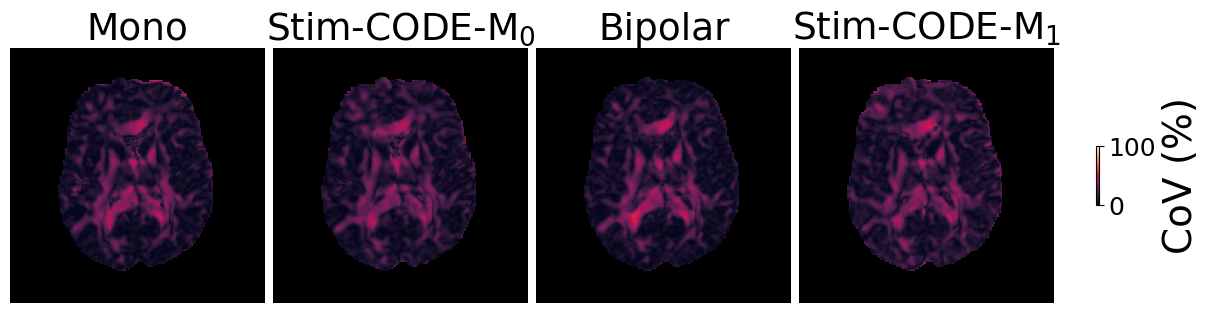


=== Plotting volunteer: V002 ===


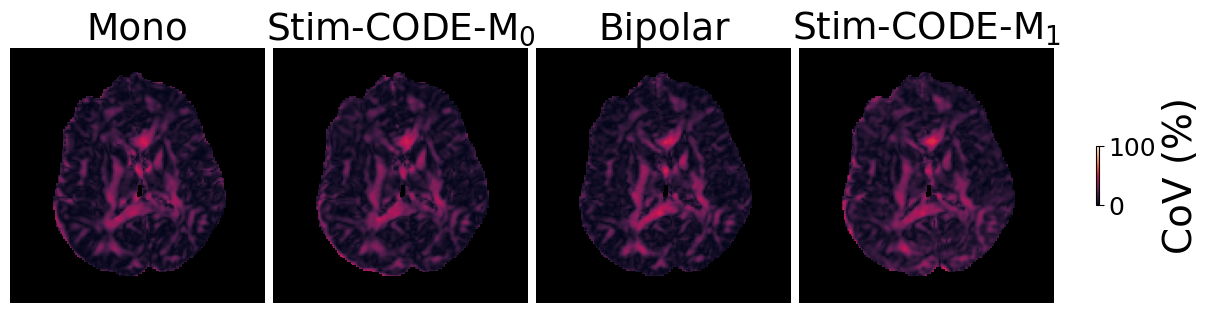


=== Plotting volunteer: V003 ===


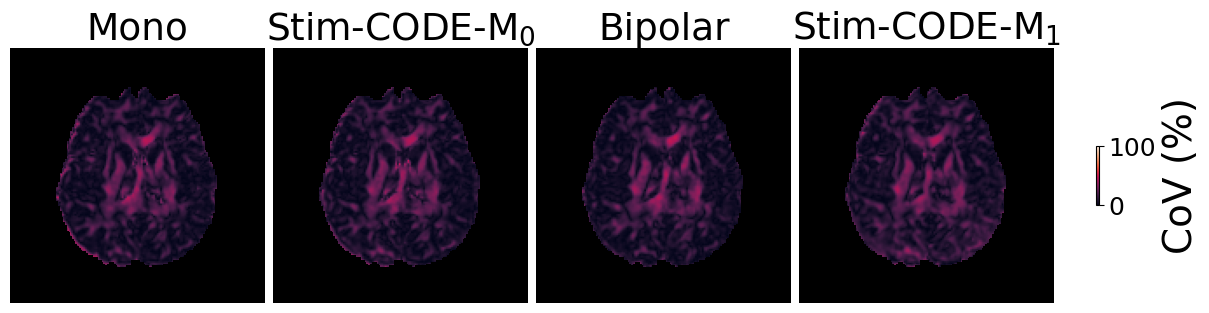


=== Plotting volunteer: V004 ===


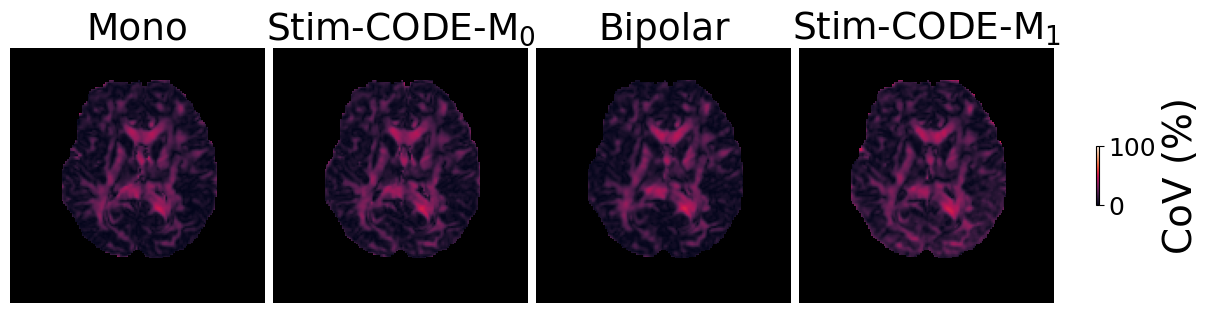


=== Plotting volunteer: V005 ===


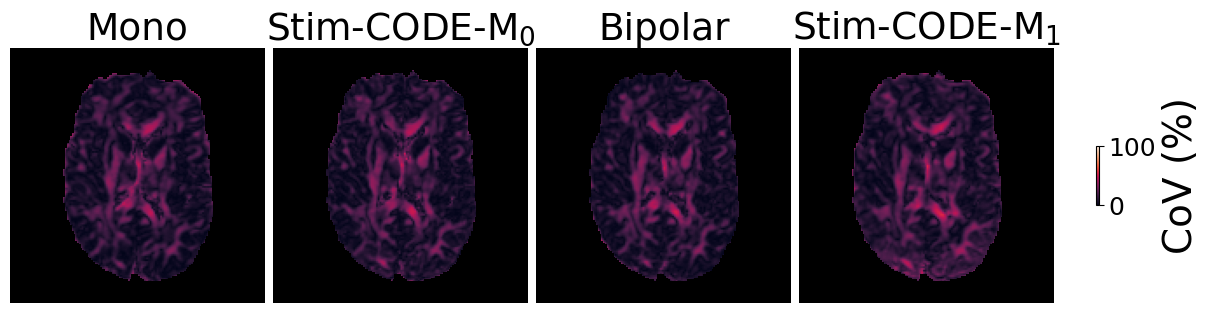


=== Plotting volunteer: V006 ===


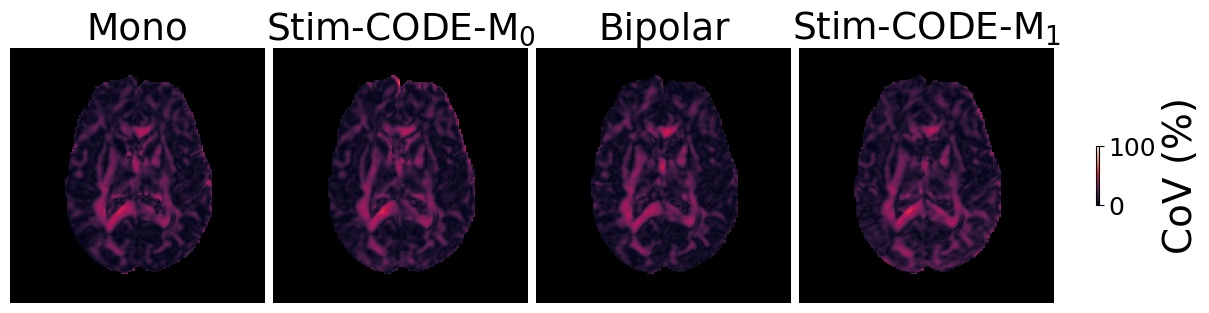


=== Plotting volunteer: V007 ===


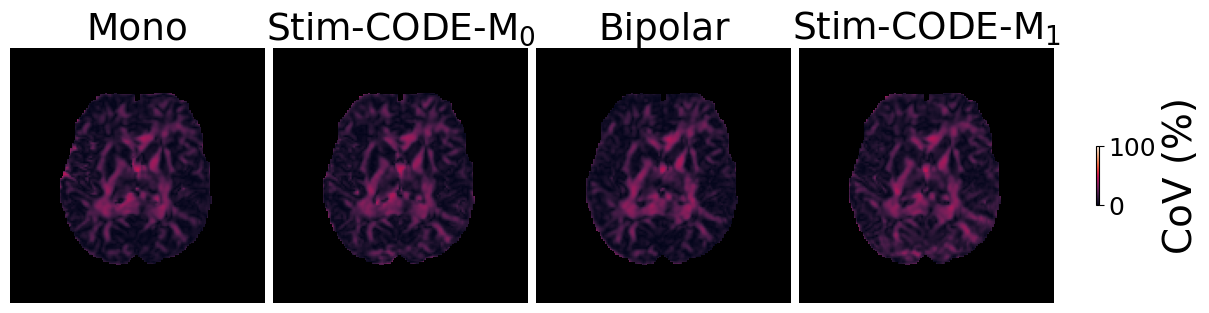


=== Plotting volunteer: V008 ===


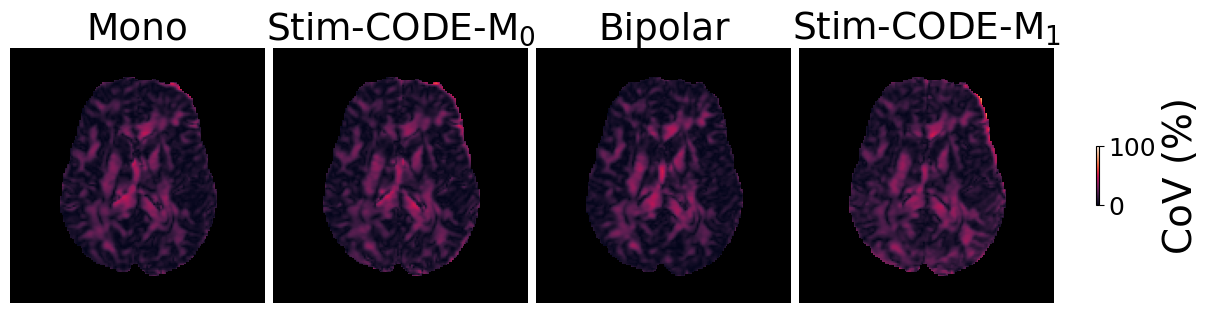


=== Plotting volunteer: V009 ===


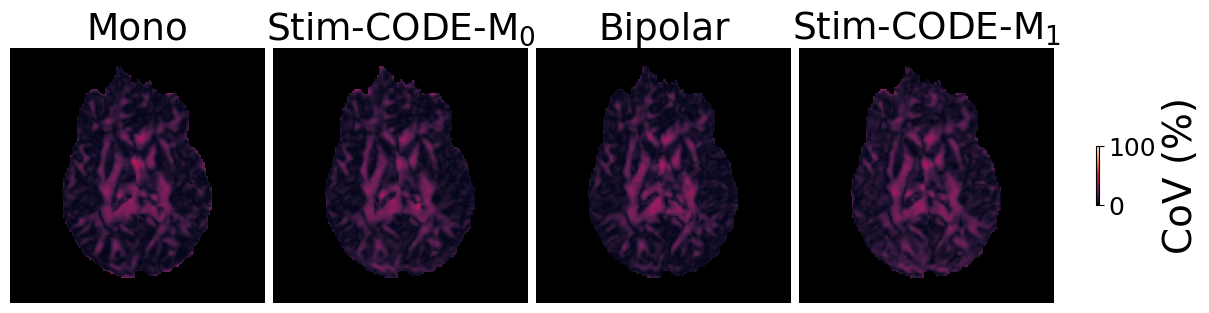


=== Plotting volunteer: V010 ===


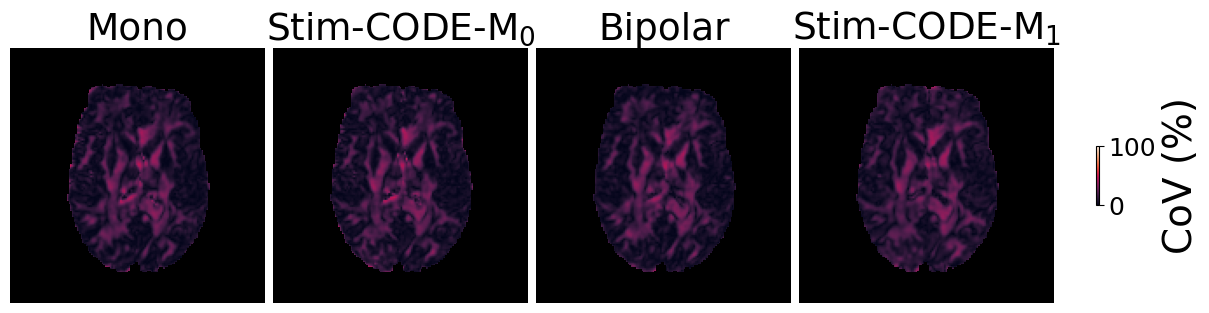

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from skimage.segmentation import find_boundaries

mpl.rcParams['axes.labelweight'] = 'normal'
mpl.rcParams['axes.titleweight'] = 'normal'

rocket_cmap = sns.color_palette("rocket", as_cmap=True)

# ------------------------
# Settings
# ------------------------
plot_slices = {
    'V001': 0, 'V002': 0, 'V003': 0, 'V004': 0, 'V005': 0,
    'V006': 0, 'V007': 0, 'V008': 0, 'V009': 0, 'V010': 0,
    'Phantom': 0, 'Phantom_01B': 0, 'Phantom_Sphere': 0,
    'Phantom_DWI': 0, 'Phantom_New': 0,
}

scans_to_plot = data_folders

# Font sizes
title_fs = 27
ylabel_fs = 28
tick_fs = 18

# Color scale for CoV (%)  
cov_vmin, cov_vmax = 0, 100  # adjust depending on expected CoV range in %

# ------------------------
# Loop over volunteers
# ------------------------
for volunteer in volunteers:
    print(f"\n=== Plotting volunteer: {volunteer} ===")
    
    slice_idx = plot_slices[volunteer]
    n_rows = 1  # Only CoV for now
    n_cols = len(scans_to_plot)
    
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 6), constrained_layout=True)
    
    if n_rows == 1:
        axs = np.array(axs).reshape(1, n_cols)
    if n_cols == 1:
        axs = axs[:, np.newaxis]

    for col_idx, folder in enumerate(scans_to_plot):
        try:
            idx_folder = data_folders.index(folder)
        except ValueError:
            print(f"⚠️ Folder {folder} not found for {volunteer}, skipping")
            continue

        # ------------------------
        # Get voxel-wise CoV for this scan
        # ------------------------
        cov_map = cov_all_vols[volunteer][idx_folder] * 100  # convert to percent

        # Apply brain mask for slice
        mask_slice = mask_all_vols[volunteer][idx_folder][:, :, slice_idx]
        cov_masked = np.copy(cov_map[:, :, slice_idx])
        cov_masked[np.isnan(mask_slice)] = np.nan

        # ------------------------
        # Black background
        # ------------------------
        base_img = np.zeros_like(cov_masked)
        axs[0, col_idx].imshow(base_img, cmap='gray', vmin=cov_vmin, vmax=cov_vmax)

        # Overlay CoV slice on top
        im = axs[0, col_idx].imshow(cov_masked, cmap=rocket_cmap, vmin=cov_vmin, vmax=cov_vmax)
        axs[0, col_idx].set_title(col_labels[col_idx], fontsize=title_fs)
        axs[0, col_idx].axis('off')

    # ------------------------
    # Colorbar for whole figure
    # ------------------------
    cbar = fig.colorbar(im, ax=axs, orientation='vertical', fraction=0.02, pad=0.04,shrink = 0.1)
    cbar.set_label('CoV (%)', fontsize=ylabel_fs)
    cbar.ax.tick_params(labelsize=tick_fs)

    plt.show()
    fig.savefig(f'fig_cov_{volunteer}.svg', dpi=300, bbox_inches='tight')


=== Plotting brain + edge mask for volunteer: V001 ===


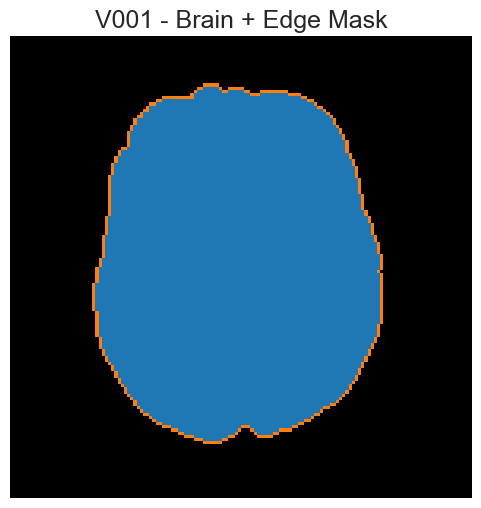


=== Plotting brain + edge mask for volunteer: V002 ===


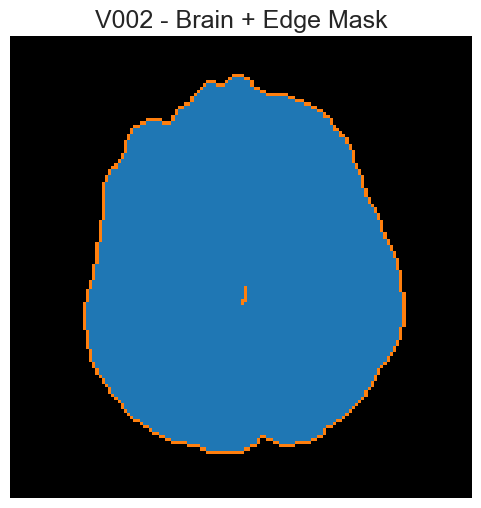


=== Plotting brain + edge mask for volunteer: V003 ===


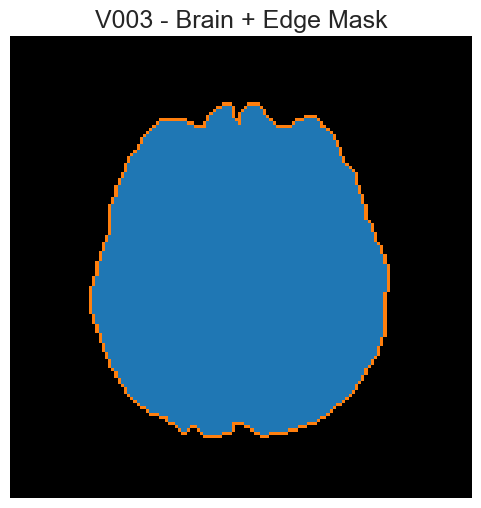


=== Plotting brain + edge mask for volunteer: V004 ===


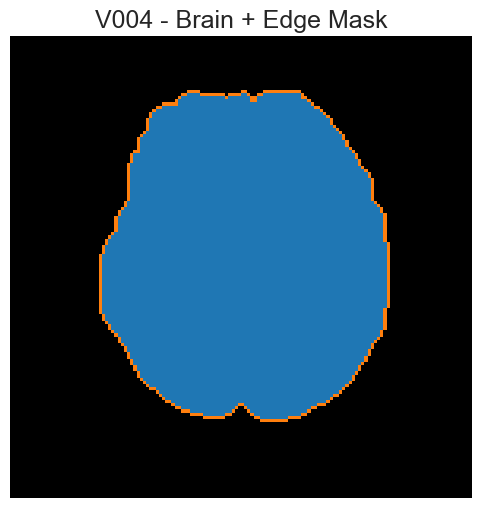


=== Plotting brain + edge mask for volunteer: V005 ===


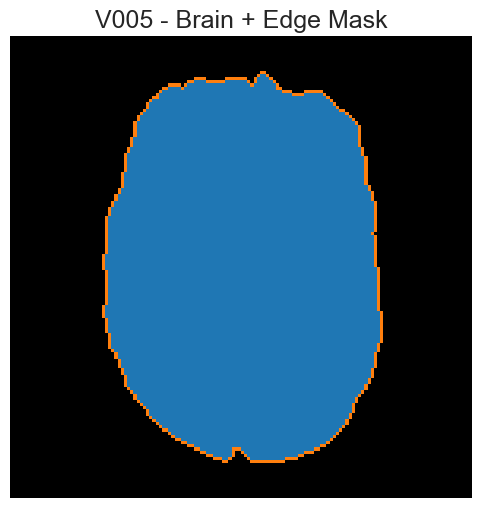


=== Plotting brain + edge mask for volunteer: V006 ===


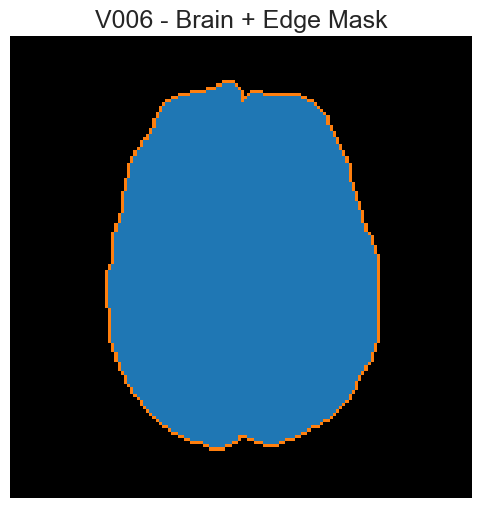


=== Plotting brain + edge mask for volunteer: V007 ===


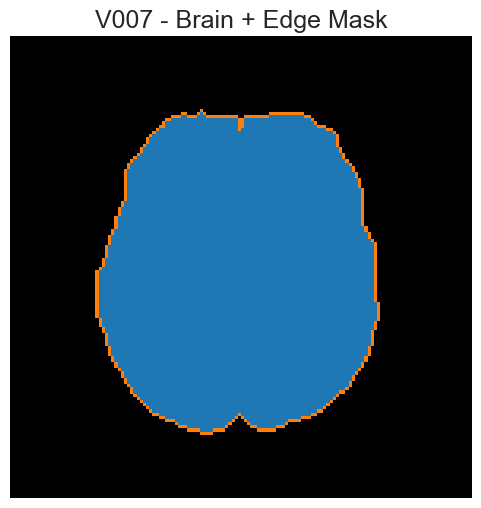


=== Plotting brain + edge mask for volunteer: V008 ===


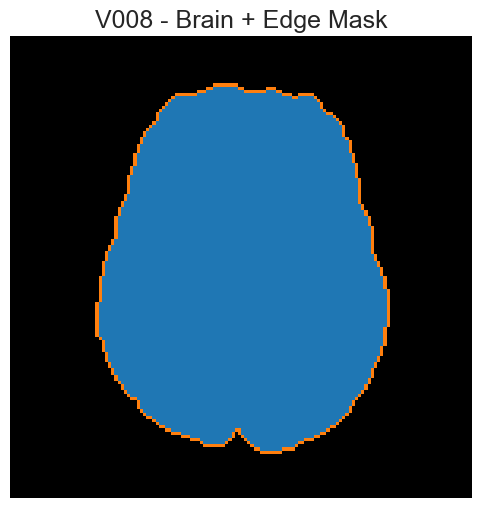


=== Plotting brain + edge mask for volunteer: V009 ===


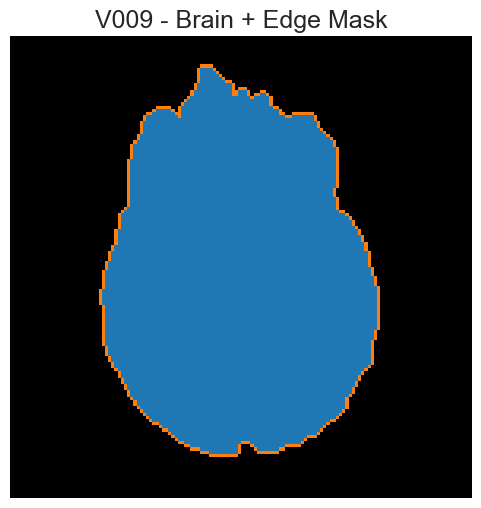


=== Plotting brain + edge mask for volunteer: V010 ===


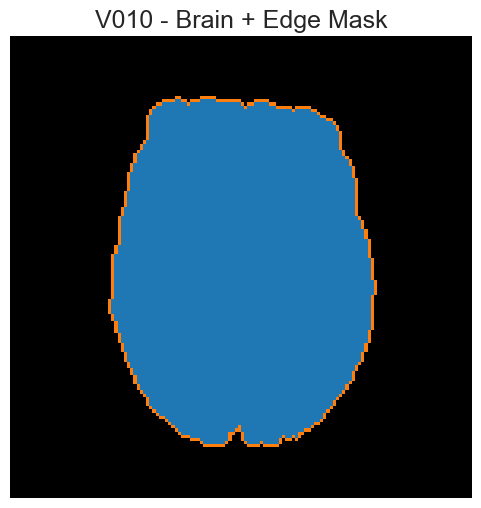

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import find_boundaries

# ------------------------
# Settings
# ------------------------
plot_slice_idx = 0  # slice to visualize

# Define colors (normalized RGB)
COLOR_WHOLE = np.array([31, 119, 180]) / 255.0   # #1f77b4
COLOR_EDGE  = np.array([255, 127,   14]) / 255.0 # #ff7f0e

# ------------------------
# Loop over volunteers
# ------------------------
for volunteer in volunteers:
    print(f"\n=== Plotting brain + edge mask for volunteer: {volunteer} ===")

    # Pick the first mask
    mask = mask_all_vols[volunteer][0]

    # Slice
    mask_slice = mask[:, :, plot_slice_idx]

    # Whole brain mask (boolean)
    brain_mask_bool = ~np.isnan(mask_slice)

    # Edge of the brain mask
    edge_mask = find_boundaries(brain_mask_bool, mode='outer')

    # ------------------------
    # Create RGB image
    # ------------------------
    img_rgb = np.zeros((*brain_mask_bool.shape, 3), dtype=float)  # black background

    # Whole brain → blue
    img_rgb[brain_mask_bool] = COLOR_WHOLE

    # Edge → orange (overwrite on top)
    img_rgb[edge_mask] = COLOR_EDGE

    # ------------------------
    # Plot
    # ------------------------
    plt.figure(figsize=(6, 6))
    plt.imshow(img_rgb)
    plt.title(f"{volunteer} - Brain + Edge Mask", fontsize=18)
    plt.axis('off')
    plt.show()

In [18]:
from itertools import combinations
import numpy as np
import pandas as pd
from scipy.stats import shapiro, friedmanchisquare, wilcoxon, ttest_rel
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.anova import AnovaRM

# =============================================================
# Build scan_cov dictionary for each mask type
# =============================================================
mask_types = ['Whole Brain', 'Edge']

scan_cov = {scan: {mask_type: [] for mask_type in mask_types} for scan in data_folders}

for volunteer in volunteers:
    for i, scan in enumerate(data_folders):
        if i < len(median_cov_all_vols[volunteer]):
            scan_cov[scan]['Whole Brain'].append(median_cov_all_vols[volunteer][i]*100)
            scan_cov[scan]['Edge'].append(median_cov_edge_all_vols[volunteer][i]*100)

# =============================================================
# Statistics function
# =============================================================
def compute_stats_cov(scan_cov, scans, mask_type, alpha_global=0.05):
    """
    Compute repeated-measures statistics for CoV (whole brain or edge)
    """

    # Build subjects × scans matrix
    X = np.array([[scan_cov[scan][mask_type][i] for scan in scans]
                  for i in range(len(scan_cov[scans[0]][mask_type]))], dtype=float)

    # Remove subjects with missing values
    X = X[np.all(np.isfinite(X), axis=1)]
    n_subjects, n_conditions = X.shape

    # Long-form DataFrame for AnovaRM
    df = pd.DataFrame(X, columns=scans)
    df['subject'] = np.arange(n_subjects)
    df_long = df.melt(
        id_vars='subject',
        value_vars=scans,
        var_name='condition',
        value_name='value'
    )

    # ------------------------------------------------------------
    # Global test
    # ------------------------------------------------------------
    try:
        residuals = (
            df_long['value'].values
            - df_long.groupby('subject')['value'].transform('mean').values
        )
        _, p_norm = shapiro(residuals)

        if p_norm > 0.05:
            aovrm = AnovaRM(df_long, 'value', 'subject', within=['condition'])
            res = aovrm.fit()
            p_global = res.anova_table['Pr > F'][0]
            test_name = "Repeated-measures ANOVA"
        else:
            _, p_global = friedmanchisquare(*X.T)
            test_name = "Friedman test"

    except Exception as e:
        print("Global test failed:", e)
        test_name = "Failed"
        p_global = np.nan

    # ------------------------------------------------------------
    # Post-hoc (only if global significant)
    # ------------------------------------------------------------
    pairs = []
    pvals_corr = []

    if p_global < alpha_global:
        pairs = list(combinations(range(n_conditions), 2))
        pvals = []

        if test_name == "Repeated-measures ANOVA":
            for i, j in pairs:
                _, p = ttest_rel(X[:, i], X[:, j])
                pvals.append(p)
        else:
            for i, j in pairs:
                _, p = wilcoxon(X[:, i], X[:, j])
                pvals.append(p)

        _, pvals_corr, _, _ = multipletests(pvals, method='holm-sidak')

    print(f"{mask_type} | {test_name}, p_global = {p_global:.4g}")
    return pairs, pvals_corr, test_name, p_global

# =============================================================
# Compute statistics for both mask types
# =============================================================
results_cov = {}
for mask_type in mask_types:
    pairs, pvals_corr, test_name, p_global = compute_stats_cov(scan_cov, data_folders, mask_type)
    results_cov[mask_type] = {
        'pairs': pairs,
        'pvals': pvals_corr,
        'test_name': test_name,
        'p_global': p_global
    }

# =============================================================
# Print results
# =============================================================
def print_cov_stats(results_cov, scan_cov, scans):
    for mask_type in results_cov:
        pairs = results_cov[mask_type]['pairs']
        pvals = results_cov[mask_type]['pvals']
        medians = {scan: np.nanmedian(scan_cov[scan][mask_type]) for scan in scans}

        print(f"\nSignificance results for {mask_type}:")
        for (i, j), p in zip(pairs, pvals):
            if p < 0.05:
                scan_i = scans[i]
                scan_j = scans[j]

                med_i = medians[scan_i]
                med_j = medians[scan_j]
                lower = scan_i if med_i < med_j else scan_j

                print(
                    f"{scan_i} vs {scan_j}: "
                    f"p_corr = {p:.4g} (✓), "
                    f"median = {med_i:.2f} vs {med_j:.2f}, "
                    f"lower: {lower}"
                )

print_cov_stats(results_cov, scan_cov, data_folders)


Whole Brain | Friedman test, p_global = 1.38e-06
Edge | Repeated-measures ANOVA, p_global = 5.358e-07

Significance results for Whole Brain:
trap_mmt0_Ncalib2 vs gropt_mmt0_Ncalib2: p_corr = 0.01166 (✓), median = 8.39 vs 9.02, lower: trap_mmt0_Ncalib2
trap_mmt0_Ncalib2 vs trap_mmt1_Ncalib2: p_corr = 0.01166 (✓), median = 8.39 vs 7.99, lower: trap_mmt1_Ncalib2
trap_mmt0_Ncalib2 vs gropt_mmt1_Ncalib2: p_corr = 0.01166 (✓), median = 8.39 vs 10.64, lower: trap_mmt0_Ncalib2
gropt_mmt0_Ncalib2 vs trap_mmt1_Ncalib2: p_corr = 0.01166 (✓), median = 9.02 vs 7.99, lower: trap_mmt1_Ncalib2
gropt_mmt0_Ncalib2 vs gropt_mmt1_Ncalib2: p_corr = 0.01166 (✓), median = 9.02 vs 10.64, lower: gropt_mmt0_Ncalib2
trap_mmt1_Ncalib2 vs gropt_mmt1_Ncalib2: p_corr = 0.01166 (✓), median = 7.99 vs 10.64, lower: trap_mmt1_Ncalib2

Significance results for Edge:
trap_mmt0_Ncalib2 vs trap_mmt1_Ncalib2: p_corr = 0.00308 (✓), median = 14.71 vs 10.80, lower: trap_mmt1_Ncalib2
gropt_mmt0_Ncalib2 vs trap_mmt1_Ncalib2: p_co

In [19]:
# ============================================================
# Bootstrap CI function
# ============================================================
def bootstrap_ci(data):
    data = np.array(data)
    N    = data.shape[0]
    Nbs  = 1000
    
    np.random.seed(0)
    bs_idx = np.random.randint(0, N, (N, Nbs))
    bs     = data[bs_idx]

    lower_bound = np.percentile(bs, 2.5, axis = 0).mean()
    upper_bound = np.percentile(bs, 97.5, axis = 0).mean()
    CI_low  = lower_bound
    CI_high = upper_bound
    return [np.nanmedian(data),CI_low, CI_high]

Mono                 | Whole Brain    8.39%  [  7.95%,   8.89%]
Stim-CODE-M$_0$      | Whole Brain    9.02%  [  8.31%,   9.48%]
Bipolar              | Whole Brain    7.99%  [  7.42%,   8.16%]
Stim-CODE-M$_1$      | Whole Brain   10.64%  [  9.66%,  11.64%]
Mono                 | Edge          14.71%  [ 12.91%,  17.52%]
Stim-CODE-M$_0$      | Edge          15.66%  [ 13.13%,  18.19%]
Bipolar              | Edge          10.80%  [  8.85%,  13.89%]
Stim-CODE-M$_1$      | Edge          16.76%  [ 13.71%,  23.10%]


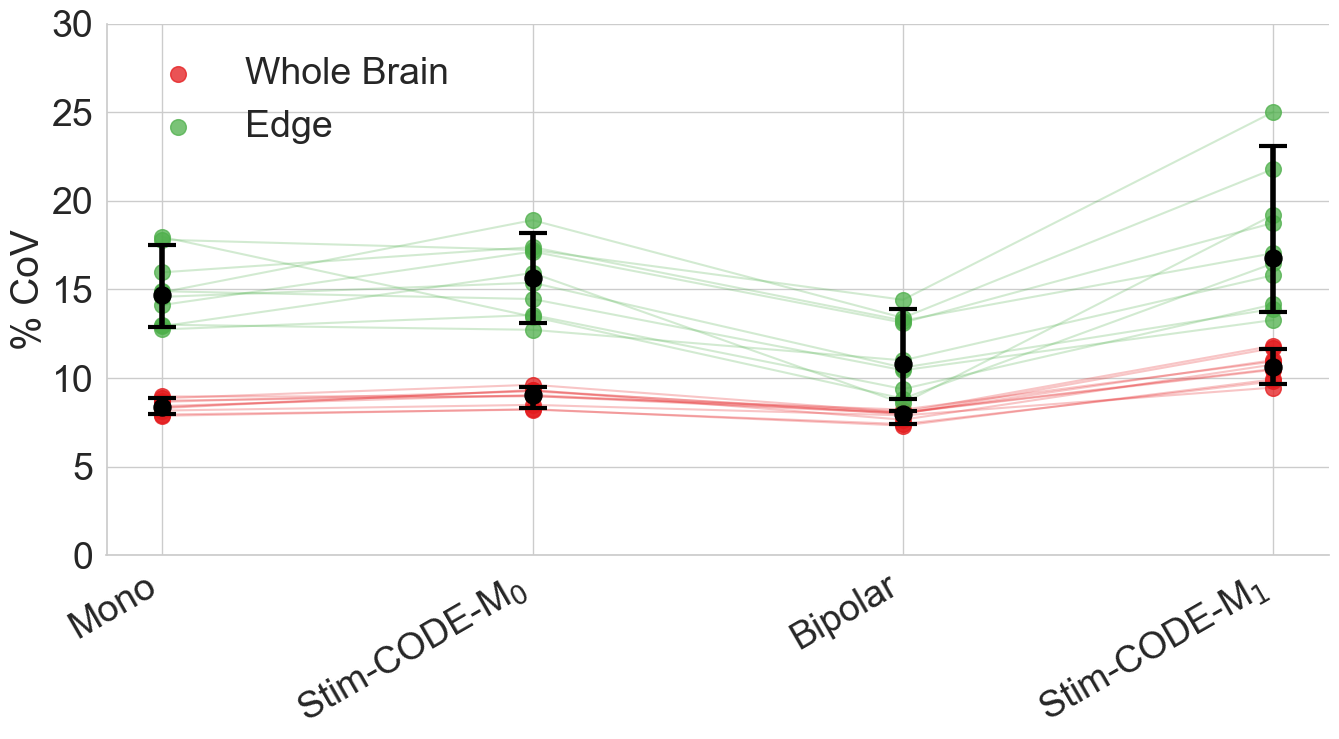

In [20]:
# ============================================================
# Scatter + point plot of median %CoV per scan
# Whole Brain and Edge on the same axis
# with bootstrapped 95% CI
# + significance brackets (Holm-corrected)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.transforms as mtransforms

# ====================================================
#  GLOBAL FONT + STYLE CONTROL
# ====================================================
TITLE_FONTSIZE = 24
LABEL_FONTSIZE = 28
TICK_FONTSIZE  = 27
SCATTER_SIZE   = 128
MEDIAN_SIZE    = 150
CI_LINEWIDTH   = 4
CI_CAPSIZE     = 10
CI_CAPTHICK    = 3

sns.set_theme(style="whitegrid")

plt.rcParams.update({
    "font.size": TICK_FONTSIZE,
    "axes.labelsize": LABEL_FONTSIZE,
    "axes.titlesize": TITLE_FONTSIZE,
    "xtick.labelsize": TICK_FONTSIZE,
    "ytick.labelsize": TICK_FONTSIZE,
})

# ====================================================
# Masks to plot
# ====================================================
mask_labels  = ['Whole Brain', 'Edge']
mask_colors  = [sns.color_palette('Set1',3)[0], sns.color_palette('Set1',3)[2]]
mask_markers = ['o', 'o']

# ====================================================
# Scan labels
# ====================================================
col_labels = [
    'Mono',
    'Stim-CODE-M$_0$',
    'Bipolar',
    'Stim-CODE-M$_1$',
]

# ====================================================
# Significance helpers
# ====================================================
def p_to_star(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return None


def add_sig_bracket(ax, x1, x2, y, text, h=0.4, lw=2, text_offset_pts=-35.):
    ax.plot(
        [x1, x1, x2, x2],
        [y, y + h, y + h, y],
        lw=lw,
        color='black',
        clip_on=False
    )

    trans = ax.transData + mtransforms.ScaledTranslation(
        0, text_offset_pts / 72., ax.figure.dpi_scale_trans
    )

    ax.text(
        (x1 + x2) / 2,
        y + h,
        text,
        ha='center',
        va='bottom',
        transform=trans,
        fontsize=TICK_FONTSIZE
    )

# ====================================================
# Plot
# ====================================================
fig, ax = plt.subplots(figsize=(14, 8))
xpos = np.arange(len(data_folders))
width = 0  # offset width between masks

# ------------------------------------------------------------
# (1) Paired volunteer trajectories
# ------------------------------------------------------------
for m_idx, mask_type in enumerate(['whole', 'edge']):
    for volunteer in median_cov_all_vols:
        y_vals, x_vals = [], []

        for i, scan in enumerate(data_folders):
            # choose the right data
            if mask_type == 'whole':
                if i < len(median_cov_all_vols[volunteer]):
                    val = 100 * median_cov_all_vols[volunteer][i]  # scale to %
            else:
                if i < len(median_cov_edge_all_vols[volunteer]):
                    val = 100 * median_cov_edge_all_vols[volunteer][i]  # scale to %

            # make sure it's scalar
            if np.isscalar(val) and np.isfinite(val):
                y_vals.append(val)
                x_vals.append(xpos[i] + (m_idx-0.5)*width)

        if len(y_vals) > 1:
            ax.plot(
                x_vals,
                y_vals,
                color=mask_colors[m_idx],
                alpha=0.25,
                lw=1.5,
                zorder=1
            )

# ------------------------------------------------------------
# (2) Scatter + bootstrap medians
# ------------------------------------------------------------
for m_idx, mask_type in enumerate(['whole', 'edge']):

    # Rebuild scan_cov for this mask
    scan_cov = {scan: [] for scan in data_folders}

    for volunteer in median_cov_all_vols:
        for i, scan in enumerate(data_folders):
            if mask_type == 'whole':
                if i < len(median_cov_all_vols[volunteer]):
                    scan_cov[scan].append(100 * median_cov_all_vols[volunteer][i])
            else:
                if i < len(median_cov_edge_all_vols[volunteer]):
                    scan_cov[scan].append(100 * median_cov_edge_all_vols[volunteer][i])

    for i, scan in enumerate(data_folders):
        y = np.asarray(scan_cov[scan], dtype=float)
        y = y[np.isfinite(y)]

        # Correct x-array to match y length
        x_array = np.full_like(y, xpos[i] + (m_idx-0.5)*width, dtype=float)

        # Scatter
        ax.scatter(
            x_array,
            y,
            s=SCATTER_SIZE,
            alpha=0.75,
            color=mask_colors[m_idx],
            marker=mask_markers[m_idx],
            zorder=3,
            label=mask_labels[m_idx] if i==0 else None
        )

        # Bootstrap CI
        median_val, lo, hi = bootstrap_ci(y)

        ax.errorbar(
            xpos[i] + (m_idx-0.5)*width,
            median_val,
            yerr=[[median_val - lo], [hi - median_val]],
            fmt=mask_markers[m_idx],
            markersize=np.sqrt(MEDIAN_SIZE),
            lw=CI_LINEWIDTH,
            capsize=CI_CAPSIZE,
            capthick=CI_CAPTHICK,
            color='black',
            zorder=10
        )

        print(
            f"{col_labels[i]:<20s} | {mask_labels[m_idx]:<12s} "
            f"{median_val:6.2f}%  [{lo:6.2f}%, {hi:6.2f}%]"
        )

# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------
ax.set_xticks(xpos)
ax.set_xticklabels(col_labels, rotation=30, ha='right')
ax.set_ylabel('% CoV')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=False, fontsize=TICK_FONTSIZE)
ax.set_ylim(0,30)
plt.tight_layout()
plt.show()

fig.savefig(
    'fig_percent_cov_median_allvols.svg',
    dpi=300,
    bbox_inches='tight'
)

Mono                 | Whole Brain    8.39%  [  7.95%,   8.89%]
Stim-CODE-M$_0$      | Whole Brain    9.02%  [  8.31%,   9.48%]
Bipolar              | Whole Brain    7.99%  [  7.42%,   8.16%]
Stim-CODE-M$_1$      | Whole Brain   10.64%  [  9.66%,  11.64%]
Mono                 | Edge          14.71%  [ 12.91%,  17.52%]
Stim-CODE-M$_0$      | Edge          15.66%  [ 13.13%,  18.19%]
Bipolar              | Edge          10.80%  [  8.85%,  13.89%]
Stim-CODE-M$_1$      | Edge          16.76%  [ 13.71%,  23.10%]


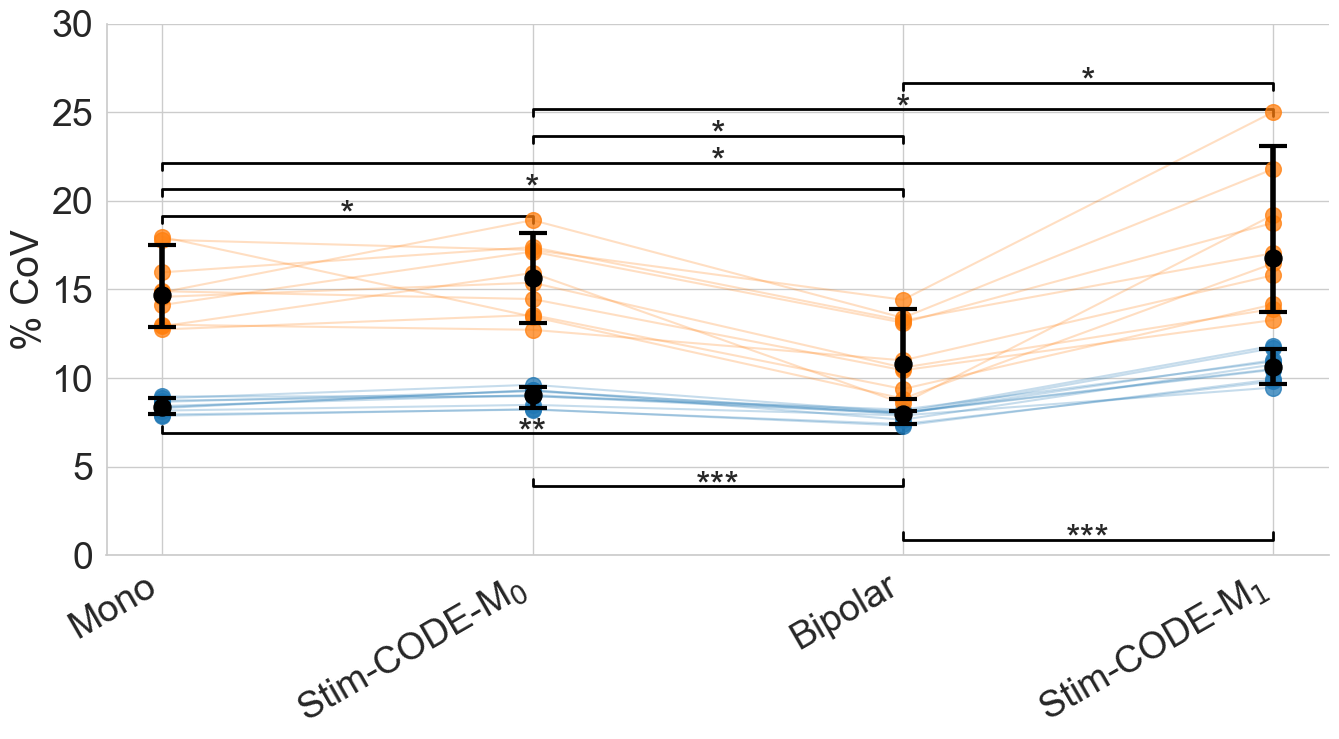

In [24]:
# ============================================================
# Scatter + point plot of median %CoV per scan
# Whole Brain and Edge on the same axis
# with bootstrapped 95% CI
# + significance brackets (Holm-corrected)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.transforms as mtransforms

# ====================================================
#  GLOBAL FONT + STYLE CONTROL
# ====================================================
TITLE_FONTSIZE = 24
LABEL_FONTSIZE = 28
TICK_FONTSIZE  = 27
SCATTER_SIZE   = 128
MEDIAN_SIZE    = 150
CI_LINEWIDTH   = 4
CI_CAPSIZE     = 10
CI_CAPTHICK    = 3

sns.set_theme(style="whitegrid")

plt.rcParams.update({
    "font.size": TICK_FONTSIZE,
    "axes.labelsize": LABEL_FONTSIZE,
    "axes.titlesize": TITLE_FONTSIZE,
    "xtick.labelsize": TICK_FONTSIZE,
    "ytick.labelsize": TICK_FONTSIZE,
})

# ====================================================
# Masks to plot
# ====================================================
mask_labels  = ['Whole Brain', 'Edge']
mask_colors  = ['#1f77b4', '#ff7f0e']  # blue=whole, orange=edge
mask_markers = ['o', 'o']

# ====================================================
# Scan labels
# ====================================================
col_labels = [
    'Mono',
    'Stim-CODE-M$_0$',
    'Bipolar',
    'Stim-CODE-M$_1$',
]

# ====================================================
# Significance helpers
# ====================================================
def p_to_star(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return None

def add_sig_bracket(ax, x1, x2, y, text, h=0.4, lw=2, text_offset_pts=-35.):
    ax.plot(
        [x1, x1, x2, x2],
        [y, y + h, y + h, y],
        lw=lw,
        color='black',
        clip_on=False
    )

    trans = ax.transData + mtransforms.ScaledTranslation(
        0, text_offset_pts / 72., ax.figure.dpi_scale_trans
    )

    ax.text(
        (x1 + x2) / 2,
        y + h,
        text,
        ha='center',
        va='bottom',
        transform=trans,
        fontsize=TICK_FONTSIZE
    )

# ====================================================
# Plot
# ====================================================
fig, ax = plt.subplots(figsize=(14, 8))
xpos = np.arange(len(data_folders))
width = 0  # offset width between masks

# ------------------------------------------------------------
# (1) Paired volunteer trajectories
# ------------------------------------------------------------
for m_idx, mask_type in enumerate(['Whole Brain', 'Edge']):
    for volunteer in median_cov_all_vols:
        y_vals, x_vals = [], []

        for i, scan in enumerate(data_folders):
            if mask_type == 'Whole Brain':
                if i < len(median_cov_all_vols[volunteer]):
                    val = 100 * median_cov_all_vols[volunteer][i]
            else:
                if i < len(median_cov_edge_all_vols[volunteer]):
                    val = 100 * median_cov_edge_all_vols[volunteer][i]

            if np.isscalar(val) and np.isfinite(val):
                y_vals.append(val)
                x_vals.append(xpos[i] + (m_idx-0.5)*width)

        if len(y_vals) > 1:
            ax.plot(
                x_vals,
                y_vals,
                color=mask_colors[m_idx],
                alpha=0.25,
                lw=1.5,
                zorder=1
            )

# ------------------------------------------------------------
# (2) Scatter + bootstrap medians
# ------------------------------------------------------------
for m_idx, mask_type in enumerate(['Whole Brain', 'Edge']):
    # Rebuild scan_cov array for this mask
    scan_vals = {scan: [] for scan in data_folders}
    for volunteer in median_cov_all_vols:
        for i, scan in enumerate(data_folders):
            if mask_type == 'Whole Brain':
                if i < len(median_cov_all_vols[volunteer]):
                    scan_vals[scan].append(100 * median_cov_all_vols[volunteer][i])
            else:
                if i < len(median_cov_edge_all_vols[volunteer]):
                    scan_vals[scan].append(100 * median_cov_edge_all_vols[volunteer][i])

    for i, scan in enumerate(data_folders):
        y = np.asarray(scan_vals[scan], dtype=float)
        y = y[np.isfinite(y)]

        x_array = np.full_like(y, xpos[i] + (m_idx-0.5)*width, dtype=float)

        ax.scatter(
            x_array,
            y,
            s=SCATTER_SIZE,
            alpha=0.75,
            color=mask_colors[m_idx],
            marker=mask_markers[m_idx],
            zorder=3,
            label=mask_labels[m_idx] if i==0 else None
        )

        median_val, lo, hi = bootstrap_ci(y)

        ax.errorbar(
            xpos[i] + (m_idx-0.5)*width,
            median_val,
            yerr=[[median_val - lo], [hi - median_val]],
            fmt=mask_markers[m_idx],
            markersize=np.sqrt(MEDIAN_SIZE),
            lw=CI_LINEWIDTH,
            capsize=CI_CAPSIZE,
            capthick=CI_CAPTHICK,
            color='black',
            zorder=10
        )

        print(f"{col_labels[i]:<20s} | {mask_labels[m_idx]:<12s} "
              f"{median_val:6.2f}%  [{lo:6.2f}%, {hi:6.2f}%]")

# ------------------------------------------------------------
# (3) Significance brackets
# ------------------------------------------------------------
for m_idx, mask_type in enumerate(['Whole Brain', 'Edge']):
    pairs = results_cov[mask_type]['pairs']
    pvals = results_cov[mask_type]['pvals']

    if not pairs:
        continue

    # Determine starting height for brackets
    if mask_type == 'Whole Brain':
        y_start = max([np.nanmedian(scan_vals[scan]) for scan in data_folders]) + 2
        h = 0.4
        text_offset = -13
    else:
        y_start = min([np.nanmedian(scan_vals[scan]) for scan in data_folders]) - 2
        h = -0.4
        text_offset = -13

    spacing = 1.5
    for idx, ((i, j), p) in enumerate(zip(pairs, pvals)):
        star = p_to_star(p)
        if star is None:
            continue
        y = y_start + idx * spacing if h > 0 else y_start - idx * spacing
        add_sig_bracket(
            ax,
            xpos[i] + (m_idx-0.5)*width,
            xpos[j] + (m_idx-0.5)*width,
            y,
            star,
            h=h,
            text_offset_pts=text_offset
        )

# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------
ax.set_xticks(xpos)
ax.set_xticklabels(col_labels, rotation=30, ha='right')
ax.set_ylabel('% CoV')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
#Eax.legend(frameon=False, fontsize=TICK_FONTSIZE)
ax.set_ylim(0, 30)
plt.tight_layout()
plt.show()

fig.savefig(
    'fig_percent_cov_median_allvols_with_brackets.svg',
    dpi=300,
    bbox_inches='tight'
)

In [27]:
# Store medians per scan
median_whole = []
median_edge  = []

# ------------------------------------------------------------
# (2) Scatter + bootstrap medians
# ------------------------------------------------------------
for i, scan in enumerate(data_folders):
    y_whole = []
    y_edge  = []

    # Collect Whole Brain
    for volunteer in median_cov_all_vols:
        if i < len(median_cov_all_vols[volunteer]):
            y_whole.append(100 * median_cov_all_vols[volunteer][i])
    y_whole = np.asarray(y_whole, dtype=float)
    y_whole = y_whole[np.isfinite(y_whole)]
    median_whole_val, lo_w, hi_w = bootstrap_ci(y_whole)
    median_whole.append(median_whole_val)

    # Collect Edge
    for volunteer in median_cov_all_vols:
        if i < len(median_cov_edge_all_vols[volunteer]):
            y_edge.append(100 * median_cov_edge_all_vols[volunteer][i])
    y_edge = np.asarray(y_edge, dtype=float)
    y_edge = y_edge[np.isfinite(y_edge)]
    median_edge_val, lo_e, hi_e = bootstrap_ci(y_edge)
    median_edge.append(median_edge_val)
ratios = np.array(median_edge) / np.array(median_whole)  # edge / whole
ratios_1X = [f"1:{r:.2f}" for r in ratios]
print("\nMedian Edge/Whole CoV ratios per scan:")
for scan, ratio_str in zip(data_folders, ratios_1X):
    print(f"{scan:<20s} | {ratio_str}") 


Median Edge/Whole CoV ratios per scan:
trap_mmt0_Ncalib2    | 1:1.75
gropt_mmt0_Ncalib2   | 1:1.74
trap_mmt1_Ncalib2    | 1:1.35
gropt_mmt1_Ncalib2   | 1:1.57
